AMAZON DIGITAL MUSIC ANALYSIS (USING MRJOB LIBRARY WITH SAMPLE REVIEWS)

In [1]:
%pip install mrjob textblob matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
from collections import Counter, defaultdict
from textblob import TextBlob
import matplotlib.pyplot as plt
import time
import pandas as pd
import os

In [3]:
with open("Digital_Music.jsonl", "r", encoding="utf-8") as f:
    first_review = json.loads(f.readline())
    
print("COMPLETE FIRST REVIEW - ALL FIELDS:")
for key, value in first_review.items():
    print(f"{key:20}: {type(value).__name__} = {value}")
print(f"\nTotal fields: {len(first_review.keys())}")

COMPLETE FIRST REVIEW - ALL FIELDS:
rating              : float = 5.0
title               : str = Nice
text                : str = If i had a dollar for how many times I have played this cd and how many times I have asked Alexa to play it, I would be rich. Love this singer along with the Black Pumas. Finding a lot of new music that I like a lot on amazon. Try new things.
images              : list = []
asin                : str = B004RQ2IRG
parent_asin         : str = B004RQ2IRG
user_id             : str = AFUOYIZBU3MTBOLYKOJE5Z35MBDA
timestamp           : int = 1618972613292
helpful_vote        : int = 0
verified_purchase   : bool = True

Total fields: 10


In [4]:
# Load product metadata (uses parent_asin which matches review parent_asin)
product_names = {}

print("Loading product metadata from meta_Digital_Music.jsonl...")
with open("meta_Digital_Music.jsonl", "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i % 50000 == 0:
            print(f"  Loaded {i:,} products...")
        meta = json.loads(line)
        
        parent_asin = meta.get('parent_asin', '')
        title = meta.get('title', '')
        
        if parent_asin and title:
            product_names[parent_asin] = title

print(f"\n Loaded metadata for {len(product_names):,} products")

Loading product metadata from meta_Digital_Music.jsonl...
  Loaded 0 products...
  Loaded 50,000 products...

 Loaded metadata for 70,530 products


In [5]:
# For products not found in metadata, extract names from review titles


review_based_names = {}
title_tracker = {}

with open("Digital_Music.jsonl", "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= 500000:  # Process 500k reviews
            break
        review = json.loads(line)
        asin = review['parent_asin']
        title = review.get('title', '')
        
        if title and len(title) > 5:
            title_lower = title.lower()
            skip_words = ['five stars', 'one star', 'two stars', 'three stars', 'four stars',
                         'great', 'good', 'ok', 'bad', 'awesome', 'terrible', 'excellent']
            if not any(word in title_lower for word in skip_words):
                if asin not in title_tracker:
                    title_tracker[asin] = {}
                title_tracker[asin][title] = title_tracker[asin].get(title, 0) + 1
        
        if i % 100000 == 0:
            print(f"  Processed {i:,} reviews...")

for asin, titles in title_tracker.items():
    if titles:
        best_title = max(titles, key=titles.get)
        review_based_names[asin] = best_title

print(f" Extracted names for {len(review_based_names):,} products")

for asin, name in review_based_names.items():
    if asin not in product_names:
        product_names[asin] = name

print(f"\n Total products with names: {len(product_names):,}")

  Processed 0 reviews...
  Processed 100,000 reviews...
 Extracted names for 48,094 products

 Total products with names: 70,537


In [6]:
# Write mrjob script for Task 2
task2_script = """
from mrjob.job import MRJob
import json

class ReviewCount(MRJob):
    def mapper(self, _, line):
        try:
            review = json.loads(line)
            yield review['parent_asin'], 1
        except:
            pass
    
    def reducer(self, product_id, counts):
        yield product_id, sum(counts)

if __name__ == '__main__':
    ReviewCount.run()
"""

with open("task2_music_review_count.py", "w") as f:
    f.write(task2_script)

print(" Created task2_music_review_count.py")

 Created task2_music_review_count.py


In [7]:
print("TASK 2: RUNNING MRJOB ON DIGITAL MUSIC DATASET")

!python task2_music_review_count.py Digital_Music.jsonl --output-dir=output_task2_music --no-conf

print("\n Task 2 completed!")

TASK 2: RUNNING MRJOB ON DIGITAL MUSIC DATASET

 Task 2 completed!


No configs specified for inline runner
Running step 1 of 1...
Creating temp directory C:\Users\ADMINI~1\AppData\Local\Temp\task2_music_review_count.Administrator.20260601.094922.640281
job output is in output_task2_music
Removing temp directory C:\Users\ADMINI~1\AppData\Local\Temp\task2_music_review_count.Administrator.20260601.094922.640281...


In [8]:
# Load results from mrjob output
task2_results = {}

output_file = "output_task2_music/part-00000"
if os.path.exists(output_file):
    with open(output_file, "r") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) == 2:
                product_id = parts[0].strip('"')
                count = int(parts[1])
                task2_results[product_id] = count

print("TASK 2: COUNT REVIEWS PER PRODUCT - FINAL RESULTS")
print(f"{'Rank':<6} {'Product ID':<20} {'Product Name':<50} {'Review Count':<12}")


sorted_results = sorted(task2_results.items(), key=lambda x: x[1], reverse=True)

for rank, (asin, count) in enumerate(sorted_results[:30], 1):
    name = product_names.get(asin, 'NAME NOT FOUND')
    name_str = str(name)[:50]
    print(f"{rank:<6} {asin:<20} {name_str:<50} {count:>10,}")

print(f"\n... and {len(sorted_results) - 30:,} more products")
print(f"\n Total unique products: {len(task2_results):,}")
print(f" Total reviews processed: {sum(task2_results.values()):,}")

TASK 2: COUNT REVIEWS PER PRODUCT - FINAL RESULTS
Rank   Product ID           Product Name                                       Review Count
1      B00003CXKT           Test Big Data 1737                                        398
2      5559166928           Elvis Presley - He Touched Me The Gospel Music - 3        319
3      B0000041CD           Mozart For Meditation                                     178
4      B000002TYX           Anthology 1                                               154
5      1401923119           The Biology of Belief: Unleashing the Power of Con        151
6      B000002TYZ           Anthology 2                                               146
7      1881405621           Meditations to Relieve Stress - Four Guided Imager         91
8      B0000041OA           Viaggio Italiano / Andrea Bocelli                          55
9      B0000040YQ           Jessye Norman - Christmastide                              45
10     B0000041MN           Beethoven: The 5 Pia

In [9]:
task3_script = """
from mrjob.job import MRJob
import json

class AvgRating(MRJob):
    def mapper(self, _, line):
        try:
            review = json.loads(line)
            yield review['parent_asin'], (review['rating'], 1)
        except:
            pass
    
    def reducer(self, product_id, values):
        total_rating = 0
        total_count = 0
        for rating, count in values:
            total_rating += rating
            total_count += count
        yield product_id, total_rating / total_count

if __name__ == '__main__':
    AvgRating.run()
"""

with open("task3_music_avg_rating.py", "w") as f:
    f.write(task3_script)

print(" Created task3_music_avg_rating.py")

 Created task3_music_avg_rating.py


In [10]:
print("TASK 3: RUNNING MRJOB ON DIGITAL MUSIC DATASET")

!python task3_music_avg_rating.py Digital_Music.jsonl --output-dir=output_task3_music --no-conf

print("\n Task 3 completed!")

TASK 3: RUNNING MRJOB ON DIGITAL MUSIC DATASET

 Task 3 completed!


No configs specified for inline runner
Running step 1 of 1...
Creating temp directory C:\Users\ADMINI~1\AppData\Local\Temp\task3_music_avg_rating.Administrator.20260601.095028.876553
job output is in output_task3_music
Removing temp directory C:\Users\ADMINI~1\AppData\Local\Temp\task3_music_avg_rating.Administrator.20260601.095028.876553...


In [12]:
# Load results
task3_results = {}

output_file = "output_task3_music/part-00000"
if os.path.exists(output_file):
    with open(output_file, "r") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) == 2:
                product_id = parts[0].strip('"')
                avg_rating = float(parts[1])
                task3_results[product_id] = avg_rating

print("TASK 3: AVERAGE STAR RATING PER PRODUCT")

filtered_results = [(asin, avg, task2_results.get(asin, 0)) 
                    for asin, avg in task3_results.items() 
                    if task2_results.get(asin, 0) >= 10]
filtered_results.sort(key=lambda x: x[1], reverse=True)

print(f"\nTop 20 Highest Rated Products (minimum 10 reviews):")
print(f"{'Rank':<6} {'Product ID':<20} {'Product Name':<50} {'Avg Rating':<12} {'Reviews':<10}")


for rank, (asin, avg, count) in enumerate(filtered_results[:20], 1):
    name = product_names.get(asin, 'NAME NOT FOUND')
    name_str = str(name)[:50]
    print(f"{rank:<6} {asin:<20} {name_str:<50} {avg:<12.2f} {count:<10,}")

all_ratings_avg = sum(task3_results.values()) / len(task3_results) if task3_results else 0
print(f"\n Global average rating across all products: {all_ratings_avg:.3f} stars")

TASK 3: AVERAGE STAR RATING PER PRODUCT

Top 20 Highest Rated Products (minimum 10 reviews):
Rank   Product ID           Product Name                                       Avg Rating   Reviews   
1      278472414X           PINK FLOYD BBC Sessions 70 Audio Cd MLPS [Mini Lon 5.00         10        
2      5553779200           Jump Into the Light                                5.00         11        
3      B000004169           Mozart: Last 5 Symphonies                          5.00         10        
4      B000008LDL           ProdName                                           5.00         10        
5      B00000JP87           Andre' Rieu: 100 Years of Strauss                  5.00         12        
6      B00001WRNI           Pinback                                            5.00         16        
7      B0000288ME           Master Collection Vol I: The Quiet Side John Micha 5.00         17        
8      B0000041F4           Giuliani: Complete Guitar Concertos                4.95

In [13]:
task4_script = """
from mrjob.job import MRJob
from mrjob.step import MRStep
import json

class TopTenProducts(MRJob):
    def mapper(self, _, line):
        try:
            review = json.loads(line)
            yield review['parent_asin'], 1
        except:
            pass
    
    def reducer_count(self, product_id, counts):
        yield None, (sum(counts), product_id)
    
    def reducer_top10(self, _, product_counts):
        for count, product_id in sorted(product_counts, reverse=True)[:10]:
            yield product_id, count
    
    def steps(self):
        return [
            MRStep(mapper=self.mapper, reducer=self.reducer_count),
            MRStep(reducer=self.reducer_top10)
        ]

if __name__ == '__main__':
    TopTenProducts.run()
"""

with open("task4_music_top10.py", "w") as f:
    f.write(task4_script)

print(" Created task4_music_top10.py")

 Created task4_music_top10.py


In [14]:
print("TASK 4: RUNNING MRJOB ON DIGITAL MUSIC DATASET")


!python task4_music_top10.py Digital_Music.jsonl --output-dir=output_task4_music --no-conf

print("\n Task 4 completed!")

TASK 4: RUNNING MRJOB ON DIGITAL MUSIC DATASET

 Task 4 completed!


No configs specified for inline runner
Running step 1 of 2...
Creating temp directory C:\Users\ADMINI~1\AppData\Local\Temp\task4_music_top10.Administrator.20260601.095138.367413
Running step 2 of 2...
job output is in output_task4_music
Removing temp directory C:\Users\ADMINI~1\AppData\Local\Temp\task4_music_top10.Administrator.20260601.095138.367413...


In [15]:
# Load results
task4_results = []

output_file = "output_task4_music/part-00000"
if os.path.exists(output_file):
    with open(output_file, "r") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) == 2:
                product_id = parts[0].strip('"')
                count = int(parts[1])
                task4_results.append((product_id, count))

print("TASK 4: TOP TEN MOST REVIEWED PRODUCTS")
print(f"{'Rank':<6} {'Product ID':<20} {'Product Name':<60} {'Review Count':<12}")


for rank, (asin, count) in enumerate(task4_results, 1):
    name = product_names.get(asin, 'NAME NOT FOUND')
    print(f"{rank:<6} {asin:<20} {str(name)[:60]:<60} {count:>10,}")

TASK 4: TOP TEN MOST REVIEWED PRODUCTS
Rank   Product ID           Product Name                                                 Review Count
1      B00003CXKT           Test Big Data 1737                                                  398
2      5559166928           Elvis Presley - He Touched Me The Gospel Music - 3pc set            319
3      B001EJH4SW           2 For 1 - Hide 'Em In Your Heart 1                                  215
4      B0000041CD           Mozart For Meditation                                               178
5      B00A44I5M2           Amazing Grace - 40 Treasured Hymns                                  164
6      B000002TYX           Anthology 1                                                         154
7      B000058983           Forever Changes                                                     151
8      1401923119           The Biology of Belief: Unleashing the Power of Consciousness        151
9      B000002TYZ           Anthology 2                    

In [16]:
task5_script = """
from mrjob.job import MRJob
import json

class HelpfulnessScore(MRJob):
    def mapper(self, _, line):
        try:
            review = json.loads(line)
            asin = review['parent_asin']
            helpful = review.get('helpful_vote', 0)
            
            if helpful > 0:
                yield asin, ('helpful', helpful)
            else:
                yield asin, ('unhelpful', 1)
        except:
            pass
    
    def reducer(self, asin, values):
        helpful_total = 0
        unhelpful_total = 0
        
        for value_type, value in values:
            if value_type == 'helpful':
                helpful_total += value
            else:
                unhelpful_total += 1
        
        total_votes = helpful_total + unhelpful_total
        score = helpful_total / total_votes if total_votes > 0 else 0
        yield asin, score

if __name__ == '__main__':
    HelpfulnessScore.run()
"""

with open("task5_music_helpfulness.py", "w") as f:
    f.write(task5_script)

print(" Created task5_music_helpfulness.py")

 Created task5_music_helpfulness.py


In [17]:
print("TASK 5: RUNNING MRJOB ON DIGITAL MUSIC DATASET")


!python task5_music_helpfulness.py Digital_Music.jsonl --output-dir=output_task5_music --no-conf

print("\n Task 5 completed!")

TASK 5: RUNNING MRJOB ON DIGITAL MUSIC DATASET

 Task 5 completed!


No configs specified for inline runner
Running step 1 of 1...
Creating temp directory C:\Users\ADMINI~1\AppData\Local\Temp\task5_music_helpfulness.Administrator.20260601.095322.383387
job output is in output_task5_music
Removing temp directory C:\Users\ADMINI~1\AppData\Local\Temp\task5_music_helpfulness.Administrator.20260601.095322.383387...


In [18]:
# Load results
task5_results = {}

output_file = "output_task5_music/part-00000"
if os.path.exists(output_file):
    with open(output_file, "r") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) == 2:
                product_id = parts[0].strip('"')
                score = float(parts[1])
                task5_results[product_id] = score

print("TASK 5: AVERAGE HELPFULNESS SCORE (CORRECTED)")
print("FORMULA: helpfulness_score = total_helpful_votes / (helpful_votes + unhelpful_votes)")
print("Range: 0 to 1 (1 = all votes were helpful)")


helpful_products = [(asin, task5_results[asin], task2_results.get(asin, 0)) 
                    for asin in task5_results if task2_results.get(asin, 0) >= 10]
helpful_products.sort(key=lambda x: x[1], reverse=True)

avg_helpfulness = sum(task5_results.values()) / len(task5_results) if task5_results else 0
print(f"\n Average Helpfulness Score across all products: {avg_helpfulness:.6f}")

print(f"\n TOP 20 MOST HELPFUL PRODUCTS (minimum 10 reviews):")
print(f"{'Rank':<6} {'Product ID':<20} {'Product Name':<50} {'Score':<10} {'Reviews':<10}")
print("-" * 100)

for rank, (asin, score, reviews) in enumerate(helpful_products[:20], 1):
    name = product_names.get(asin, 'NAME NOT FOUND')
    name_str = str(name)[:50]
    print(f"{rank:<6} {asin:<20} {name_str:<50} {score:<10.4f} {reviews:<10,}")

TASK 5: AVERAGE HELPFULNESS SCORE (CORRECTED)
FORMULA: helpfulness_score = total_helpful_votes / (helpful_votes + unhelpful_votes)
Range: 0 to 1 (1 = all votes were helpful)

 Average Helpfulness Score across all products: 0.355231

 TOP 20 MOST HELPFUL PRODUCTS (minimum 10 reviews):
Rank   Product ID           Product Name                                       Score      Reviews   
1      B00002MY88           Town to Town / Ph'lip Side / Play Thru Me          1.0000     13        
2      0875420230           Songs of Yggdrasil: Shamanic Chants from the North 0.9895     14        
3      1938774272           Silva Method                                       0.9868     10        
4      B00002456O           The Pearl Fishers                                  0.9865     20        
5      B0000057L9           Bach: Complete Suites for Solo Cello; Sonatas in G 0.9855     15        
6      B00000IIX1           Beethoven: The 5 Piano Concertos                   0.9846     10        
7      1

In [19]:
print("TASK 6: SENTIMENT ANALYSIS WITH SAMPLE REVIEWS")


from textblob import TextBlob

def analyze_text(text):
    if not text or len(text.strip()) < 5:
        return 'neutral', 0.0, 0.0
    try:
        blob = TextBlob(text[:1000])
        polarity = blob.sentiment.polarity
        subjectivity = blob.sentiment.subjectivity
        if polarity > 0.1:
            return 'positive', polarity, subjectivity
        elif polarity < -0.1:
            return 'negative', polarity, subjectivity
        else:
            return 'neutral', polarity, subjectivity
    except:
        return 'neutral', 0.0, 0.0

# Collect samples directly
direct_samples = {'positive': [], 'neutral': [], 'negative': []}
sentiment_counts = {'positive': 0, 'neutral': 0, 'negative': 0}

print("\nScanning Digital Music dataset for sample reviews...")

with open("Digital_Music.jsonl", "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= 50000:  # Sample 50,000 reviews
            break
            
        review = json.loads(line)
        text = review.get('text', '')
        rating = review.get('rating', 0)
        
        if text and len(text) > 20:
            sentiment, polarity, subjectivity = analyze_text(text)
            sentiment_counts[sentiment] += 1
            
            if len(direct_samples[sentiment]) < 5:
                direct_samples[sentiment].append({
                    'text': text[:450] + '...' if len(text) > 450 else text,
                    'rating': rating,
                    'polarity': polarity,
                    'subjectivity': subjectivity
                })

total = sum(sentiment_counts.values())
print(f"\n SENTIMENT DISTRIBUTION (based on {total:,} reviews):")
for sentiment in ['positive', 'neutral', 'negative']:
    count = sentiment_counts.get(sentiment, 0)
    pct = (count/total)*100 if total > 0 else 0
    print(f"   {sentiment.capitalize()}: {count:,} ({pct:.1f}%)")

TASK 6: SENTIMENT ANALYSIS WITH SAMPLE REVIEWS

Scanning Digital Music dataset for sample reviews...

 SENTIMENT DISTRIBUTION (based on 42,828 reviews):
   Positive: 34,623 (80.8%)
   Neutral: 6,735 (15.7%)
   Negative: 1,470 (3.4%)


In [20]:

print("SAMPLE DIGITAL MUSIC REVIEWS WITH SENTIMENT ANALYSIS RESULTS")


print("\n POSITIVE REVIEW SAMPLES:")

for i, sample in enumerate(direct_samples['positive'], 1):
    print(f"\nSample {i}:")
    print(f"  Rating: {sample['rating']} stars")
    print(f"  Polarity: {sample['polarity']:.3f} (positive > 0.1)")
    print(f"  Subjectivity: {sample['subjectivity']:.3f} (0=factual, 1=opinion)")
    print(f"  Review Text: \"{sample['text']}\"")


print("\n NEUTRAL REVIEW SAMPLES:")

for i, sample in enumerate(direct_samples['neutral'], 1):
    print(f"\nSample {i}:")
    print(f"  Rating: {sample['rating']} stars")
    print(f"  Polarity: {sample['polarity']:.3f} (between -0.1 and 0.1)")
    print(f"  Subjectivity: {sample['subjectivity']:.3f}")
    print(f"  Review Text: \"{sample['text']}\"")


print("\n NEGATIVE REVIEW SAMPLES:")

for i, sample in enumerate(direct_samples['negative'], 1):
    print(f"\nSample {i}:")
    print(f"  Rating: {sample['rating']} stars")
    print(f"  Polarity: {sample['polarity']:.3f} (negative < -0.1)")
    print(f"  Subjectivity: {sample['subjectivity']:.3f}")
    print(f"  Review Text: \"{sample['text']}\"")


print(f"\n Collected {len(direct_samples['positive'])} positive, {len(direct_samples['neutral'])} neutral, {len(direct_samples['negative'])} negative samples")

SAMPLE DIGITAL MUSIC REVIEWS WITH SENTIMENT ANALYSIS RESULTS

 POSITIVE REVIEW SAMPLES:

Sample 1:
  Rating: 5.0 stars
  Polarity: 0.283 (positive > 0.1)
  Subjectivity: 0.527 (0=factual, 1=opinion)
  Review Text: "If i had a dollar for how many times I have played this cd and how many times I have asked Alexa to play it, I would be rich. Love this singer along with the Black Pumas. Finding a lot of new music that I like a lot on amazon. Try new things."

Sample 2:
  Rating: 5.0 stars
  Polarity: 0.750 (positive > 0.1)
  Subjectivity: 0.700 (0=factual, 1=opinion)
  Review Text: "awesome sound - cant wait to see them in person - always miss them when they are in town !"

Sample 3:
  Rating: 5.0 stars
  Polarity: 0.425 (positive > 0.1)
  Subjectivity: 0.413 (0=factual, 1=opinion)
  Review Text: "This is a great cd. Good music and plays well. Seller responded back very quicky and  received it within 3 days"

Sample 4:
  Rating: 3.0 stars
  Polarity: 0.130 (positive > 0.1)
  Subjectivity: 

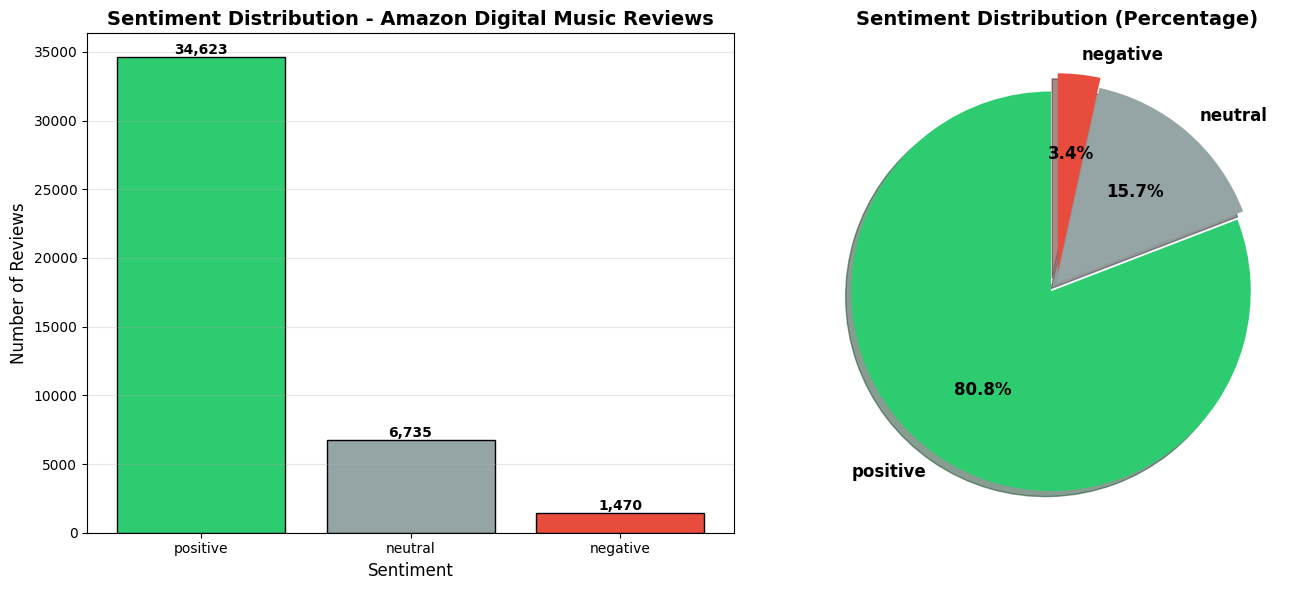

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sentiments = list(sentiment_counts.keys())
counts = list(sentiment_counts.values())

# Bar chart
colors = ['#2ecc71', '#95a5a6', '#e74c3c']
bars = ax1.bar(sentiments, counts, color=colors, edgecolor='black')
ax1.set_title('Sentiment Distribution - Amazon Digital Music Reviews', fontsize=14, fontweight='bold')
ax1.set_xlabel('Sentiment', fontsize=12)
ax1.set_ylabel('Number of Reviews', fontsize=12)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height, f'{int(height):,}', 
             ha='center', va='bottom', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Pie chart
if sum(counts) > 0:
    explode = (0.05, 0, 0.05)
    ax2.pie(counts, explode=explode, labels=sentiments, colors=colors, autopct='%1.1f%%',
            shadow=True, startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
    ax2.set_title('Sentiment Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()